In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")

SAVE_PATH = "give the path to save models and results here"
week3_SAVE_PATH = "give the path to the directory containing drift_results_2020_2022.parquet and walk_forward_results_2019.parquet here"


# ── Load data ──────────────────────────────────────────────────────────
drift    = pd.read_parquet(week3_SAVE_PATH + "drift_results_2020_2022.parquet")
baseline = pd.read_parquet(week3_SAVE_PATH + "walk_forward_results_2019.parquet")

# Clean baseline — remove anomaly months (Aug=1 record, Nov=4 records)
baseline_clean = baseline[baseline["test_size"] > 100].copy()
baseline_clean["period"] = baseline_clean["test_month"].apply(lambda m: f"2019-{m:02d}")

# Build full timeline
full = pd.concat([
    baseline_clean[["period", "xgb_mae", "xgb_mape", "lr_mae", "lr_mape"]],
    drift[["period", "xgb_mae", "xgb_mape", "lr_mae", "lr_mape"]]
], ignore_index=True)

full["period_dt"] = pd.to_datetime(full["period"], format="%Y-%m")
full = full.sort_values("period_dt").reset_index(drop=True)

print(f"Full timeline: {len(full)} months")
print(f"From: {full['period'].iloc[0]} → To: {full['period'].iloc[-1]}")
print(f"\n2019 baseline XGB MAE avg: {baseline_clean['xgb_mae'].mean():.4f}")
print(f"2019 baseline XGB MAPE avg: {baseline_clean['xgb_mape'].mean():.2f}%")

Full timeline: 45 months
From: 2019-02 → To: 2022-12

2019 baseline XGB MAE avg: 3.1896
2019 baseline XGB MAPE avg: 25.69%


SECTION 1: Page-Hinkley Test 

In [3]:
# ── SECTION 1: Page-Hinkley Test ───────────────────────────────────────
# Detects abrupt drift — fires when cumulative deviation exceeds threshold
# Best for: sudden shifts like COVID lockdown

def page_hinkley_test(series, delta=0.005, lambda_=10, alpha=0.9999):
    """
    delta  : minimum magnitude of change to detect (sensitivity)
    lambda_: threshold — higher = less sensitive, fewer false alarms
    alpha  : forgetting factor for gradual drift
    Returns: list of indices where drift was detected
    """
    drift_points = []
    m_t = 0      # running mean estimate
    U_t = 0      # cumulative sum
    M_t = 0      # minimum cumulative sum seen so far

    for i, val in enumerate(series):
        m_t = alpha * m_t + (1 - alpha) * val
        U_t = U_t + val - m_t - delta
        M_t = min(M_t, U_t)

        if (U_t - M_t) > lambda_:
            drift_points.append(i)
            # Reset after detection
            U_t = 0
            M_t = 0

    return drift_points

mae_series  = full["xgb_mae"].values
mape_series = full["xgb_mape"].values

ph_mae_points  = page_hinkley_test(mae_series,  delta=0.005, lambda_=8)
ph_mape_points = page_hinkley_test(mape_series, delta=0.05,  lambda_=50)

print("Page-Hinkley drift points (MAE series):")
for idx in ph_mae_points:
    print(f"  Index {idx} → Period: {full['period'].iloc[idx]} | XGB MAE: {full['xgb_mae'].iloc[idx]:.4f}")

print("\nPage-Hinkley drift points (MAPE series):")
for idx in ph_mape_points:
    print(f"  Index {idx} → Period: {full['period'].iloc[idx]} | XGB MAPE: {full['xgb_mape'].iloc[idx]:.2f}%")

Page-Hinkley drift points (MAE series):
  Index 2 → Period: 2019-04 | XGB MAE: 3.0008
  Index 5 → Period: 2019-07 | XGB MAE: 3.3405
  Index 8 → Period: 2019-12 | XGB MAE: 3.5263
  Index 11 → Period: 2020-03 | XGB MAE: 3.1915
  Index 13 → Period: 2020-05 | XGB MAE: 5.1185
  Index 15 → Period: 2020-07 | XGB MAE: 4.1270
  Index 17 → Period: 2020-09 | XGB MAE: 4.1051
  Index 20 → Period: 2020-12 | XGB MAE: 4.0696
  Index 23 → Period: 2021-03 | XGB MAE: 3.3205
  Index 26 → Period: 2021-06 | XGB MAE: 3.6427
  Index 29 → Period: 2021-09 | XGB MAE: 3.8405
  Index 32 → Period: 2021-12 | XGB MAE: 3.9778
  Index 35 → Period: 2022-03 | XGB MAE: 3.2888
  Index 38 → Period: 2022-06 | XGB MAE: 3.7052
  Index 41 → Period: 2022-09 | XGB MAE: 4.1061
  Index 44 → Period: 2022-12 | XGB MAE: 4.1879

Page-Hinkley drift points (MAPE series):
  Index 2 → Period: 2019-04 | XGB MAPE: 24.91%
  Index 4 → Period: 2019-06 | XGB MAPE: 25.70%
  Index 6 → Period: 2019-09 | XGB MAPE: 24.96%
  Index 8 → Period: 2019-12 

SECTION 2: ADWIN (Adaptive Windowing) 

In [4]:
# ── SECTION 2: ADWIN (Adaptive Windowing) ─────────────────────────────
# Detects gradual drift — maintains adaptive window and fires when
# two sub-windows show statistically different means
# Best for: gradual recovery drift in 2020 H2 and 2021

def adwin_detector(series, delta=0.002):
    """
    delta: confidence parameter — smaller = more sensitive
    Returns: list of indices where drift was detected
    """
    drift_points = []
    window = []

    for i, val in enumerate(series):
        window.append(val)

        # Test all possible split points in the current window
        drift_detected = False
        n = len(window)

        if n >= 4:  # need minimum window size
            for split in range(2, n - 2):
                w0 = np.array(window[:split])
                w1 = np.array(window[split:])

                mean0 = np.mean(w0)
                mean1 = np.mean(w1)

                # Hoeffding bound
                m = 1 / (1/len(w0) + 1/len(w1))
                epsilon = np.sqrt((1 / (2*m)) * np.log(4 * n / delta))

                if abs(mean0 - mean1) > epsilon:
                    drift_points.append(i)
                    window = list(w1)  # shrink window to newer half
                    drift_detected = True
                    break

    return drift_points

adwin_mae_points  = adwin_detector(mae_series,  delta=0.002)
adwin_mape_points = adwin_detector(mape_series, delta=0.002)

# Deduplicate closely spaced detections (within 2 months)
def deduplicate(points, min_gap=2):
    if not points:
        return []
    result = [points[0]]
    for p in points[1:]:
        if p - result[-1] >= min_gap:
            result.append(p)
    return result

adwin_mae_points  = deduplicate(adwin_mae_points)
adwin_mape_points = deduplicate(adwin_mape_points)

print("ADWIN drift points (MAE series):")
for idx in adwin_mae_points:
    print(f"  Index {idx} → Period: {full['period'].iloc[idx]} | XGB MAE: {full['xgb_mae'].iloc[idx]:.4f}")

print("\nADWIN drift points (MAPE series):")
for idx in adwin_mape_points:
    print(f"  Index {idx} → Period: {full['period'].iloc[idx]} | XGB MAPE: {full['xgb_mape'].iloc[idx]:.2f}%")

ADWIN drift points (MAE series):
  Index 14 → Period: 2020-06 | XGB MAE: 4.8792

ADWIN drift points (MAPE series):
  Index 5 → Period: 2019-07 | XGB MAPE: 28.75%
  Index 9 → Period: 2020-01 | XGB MAPE: 28.78%
  Index 11 → Period: 2020-03 | XGB MAPE: 31.81%
  Index 13 → Period: 2020-05 | XGB MAPE: 65.30%
  Index 15 → Period: 2020-07 | XGB MAPE: 48.23%
  Index 17 → Period: 2020-09 | XGB MAPE: 47.40%
  Index 19 → Period: 2020-11 | XGB MAPE: 43.82%
  Index 21 → Period: 2021-01 | XGB MAPE: 37.04%
  Index 23 → Period: 2021-03 | XGB MAPE: 37.72%
  Index 30 → Period: 2021-10 | XGB MAPE: 30.51%
  Index 35 → Period: 2022-03 | XGB MAPE: 27.46%
  Index 40 → Period: 2022-08 | XGB MAPE: 32.63%


SECTION 3: Combine & classify drift points

In [5]:
# ── SECTION 3: Combine & classify drift points ─────────────────────────

# COVID-19 reference events for annotation
covid_events = {
    "2020-03": "NYC first\nCOVID case",
    "2020-04": "Full\nLockdown",
    "2020-06": "Phase 1\nReopening",
    "2020-12": "Vaccine\nRollout",
    "2021-06": "Full\nReopening",
}

# Collect all unique drift points from both detectors
all_drift_indices = sorted(set(ph_mae_points + ph_mape_points +
                               adwin_mae_points + adwin_mape_points))
all_drift_indices = deduplicate(all_drift_indices, min_gap=1)

print("Combined drift detection summary:")
print(f"{'Period':<12} {'XGB MAE':<10} {'XGB MAPE':<12} {'Detected by':<30} {'Drift Type'}")
print("-" * 80)

for idx in all_drift_indices:
    period  = full["period"].iloc[idx]
    mae_val = full["xgb_mae"].iloc[idx]
    mape_val= full["xgb_mape"].iloc[idx]

    detectors = []
    if idx in ph_mae_points or idx in ph_mape_points:
        detectors.append("Page-Hinkley")
    if idx in adwin_mae_points or idx in adwin_mape_points:
        detectors.append("ADWIN")

    # Classify drift type based on magnitude and context
    if mape_val > 45:
        drift_type = "Abrupt (Severe)"
    elif mape_val > 35:
        drift_type = "Abrupt (Moderate)"
    elif mae_val < full["xgb_mae"].iloc[max(0,idx-3):idx].mean() * 0.95 if idx >= 3 else True:
        drift_type = "Gradual (Recovery)"
    else:
        drift_type = "Gradual"

    print(f"{period:<12} {mae_val:<10.4f} {mape_val:<12.2f} {', '.join(detectors):<30} {drift_type}")

Combined drift detection summary:
Period       XGB MAE    XGB MAPE     Detected by                    Drift Type
--------------------------------------------------------------------------------
2019-04      3.0008     24.91        Page-Hinkley                   Gradual (Recovery)
2019-06      3.2226     25.70        Page-Hinkley                   Gradual
2019-07      3.3405     28.75        Page-Hinkley, ADWIN            Gradual
2019-09      3.3911     24.96        Page-Hinkley                   Gradual
2019-12      3.5263     27.90        Page-Hinkley                   Gradual
2020-01      3.0909     28.78        ADWIN                          Gradual (Recovery)
2020-02      3.0091     26.90        Page-Hinkley                   Gradual (Recovery)
2020-03      3.1915     31.81        Page-Hinkley, ADWIN            Gradual
2020-04      5.1814     69.54        Page-Hinkley                   Abrupt (Severe)
2020-05      5.1185     65.30        Page-Hinkley, ADWIN            Abrupt (Sever

SECTION 4: Drift timeline visualisation 

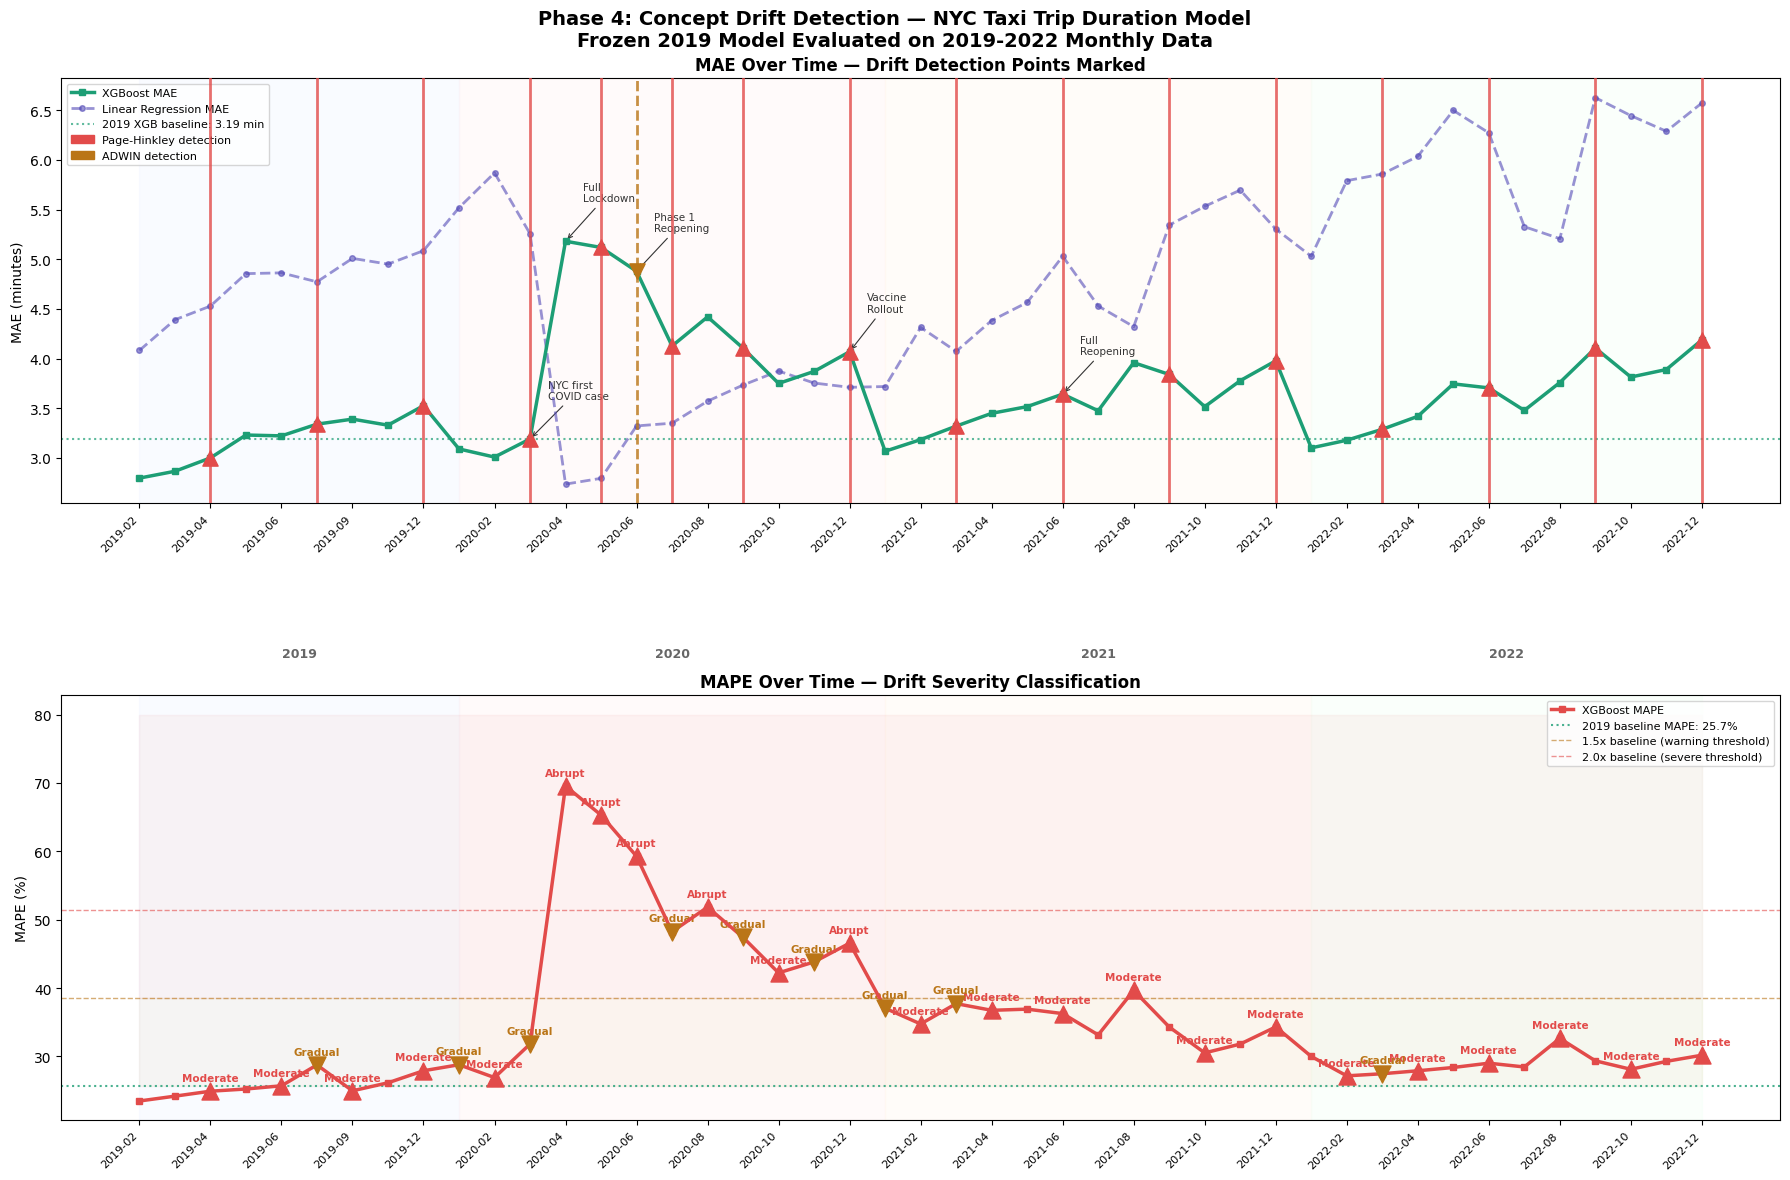

Saved: drift_detection_timeline.png


In [10]:
# ── SECTION 4: Drift timeline visualisation ────────────────────────────

fig, axes = plt.subplots(2, 1, figsize=(18, 12))
fig.suptitle("Phase 4: Concept Drift Detection — NYC Taxi Trip Duration Model\n"
             "Frozen 2019 Model Evaluated on 2019-2022 Monthly Data",
             fontsize=14, fontweight="bold")

x = range(len(full))
x_labels = full["period"].tolist()

# ── Plot 1: MAE with drift points ──
ax = axes[0]
# Shade regions by year
year_boundaries = {
    "2019": (0, len(baseline_clean)),
    "2020": (len(baseline_clean), len(baseline_clean)+12),
    "2021": (len(baseline_clean)+12, len(baseline_clean)+24),
    "2022": (len(baseline_clean)+24, len(full)),
}
shade_colors = {"2019":"#EEF2FF", "2020":"#FFF0F0", "2021":"#FFF8EC", "2022":"#F0FFF4"}
for yr, (start, end) in year_boundaries.items():
    ax.axvspan(start, min(end, len(full)-1), alpha=0.3,
               color=shade_colors[yr], label=f"_{yr}")
    ax.text((start+min(end,len(full)-1))/2, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 6,
            yr, ha="center", fontsize=9, color="#666666", fontweight="bold")

# MAE lines
ax.plot(x, full["xgb_mae"], color="#1D9E75", linewidth=2.5,
        marker="s", markersize=5, label="XGBoost MAE", zorder=5)
ax.plot(x, full["lr_mae"],  color="#534AB7", linewidth=2,
        marker="o", markersize=4, label="Linear Regression MAE",
        alpha=0.6, linestyle="--", zorder=4)

# Baseline reference line
baseline_avg = baseline_clean["xgb_mae"].mean()
ax.axhline(baseline_avg, color="#1D9E75", linewidth=1.5,
           linestyle=":", alpha=0.7, label=f"2019 XGB baseline: {baseline_avg:.2f} min")

# Page-Hinkley detections
for idx in ph_mae_points:
    ax.axvline(idx, color="#E24B4A", linewidth=2, linestyle="-",
               alpha=0.8, zorder=6)
    ax.scatter(idx, full["xgb_mae"].iloc[idx], color="#E24B4A",
               s=120, zorder=7, marker="^")

# ADWIN detections
for idx in adwin_mae_points:
    if idx not in ph_mae_points:
        ax.axvline(idx, color="#BA7517", linewidth=2, linestyle="--",
                   alpha=0.8, zorder=6)
        ax.scatter(idx, full["xgb_mae"].iloc[idx], color="#BA7517",
                   s=120, zorder=7, marker="v")

# COVID event annotations
for period, label in covid_events.items():
    if period in full["period"].values:
        idx = full[full["period"] == period].index[0]
        ax.annotate(label, xy=(idx, full["xgb_mae"].iloc[idx]),
                    xytext=(idx + 0.5, full["xgb_mae"].iloc[idx] + 0.4),
                    fontsize=7.5, color="#333333",
                    arrowprops=dict(arrowstyle="->", color="#333333", lw=0.8))

ax.set_title("MAE Over Time — Drift Detection Points Marked", fontweight="bold")
ax.set_ylabel("MAE (minutes)")
ax.set_xticks(list(x)[::2])
ax.set_xticklabels(x_labels[::2], rotation=45, ha="right", fontsize=8)
ax.legend(loc="upper left", fontsize=9)

# Custom legend for detectors
ph_patch   = mpatches.Patch(color="#E24B4A", label="Page-Hinkley detection")
adwin_patch= mpatches.Patch(color="#BA7517", label="ADWIN detection")
ax.legend(handles=ax.get_legend_handles_labels()[0] + [ph_patch, adwin_patch],
          labels=ax.get_legend_handles_labels()[1] + ["Page-Hinkley detection", "ADWIN detection"],
          loc="upper left", fontsize=8)

# ── Plot 2: MAPE with drift type classification ──
ax = axes[1]
for yr, (start, end) in year_boundaries.items():
    ax.axvspan(start, min(end, len(full)-1), alpha=0.3,
               color=shade_colors[yr])

ax.plot(x, full["xgb_mape"], color="#E24B4A", linewidth=2.5,
        marker="s", markersize=5, label="XGBoost MAPE", zorder=5)

baseline_mape = baseline_clean["xgb_mape"].mean()
ax.axhline(baseline_mape, color="#1D9E75", linewidth=1.5,
           linestyle=":", alpha=0.8, label=f"2019 baseline MAPE: {baseline_mape:.1f}%")
ax.axhline(baseline_mape * 1.5, color="#BA7517", linewidth=1,
           linestyle="--", alpha=0.6, label="1.5x baseline (warning threshold)")
ax.axhline(baseline_mape * 2.0, color="#E24B4A", linewidth=1,
           linestyle="--", alpha=0.6, label="2.0x baseline (severe threshold)")

# Fill between — show severity zones
ax.fill_between(x, baseline_mape, baseline_mape*1.5,
                alpha=0.05, color="#BA7517", label="_warn zone")
ax.fill_between(x, baseline_mape*1.5, 80,
                alpha=0.05, color="#E24B4A", label="_severe zone")

# Drift type labels
for idx in ph_mape_points:
    mape_val = full["xgb_mape"].iloc[idx]
    dtype = "Abrupt" if mape_val > 45 else "Moderate"
    ax.scatter(idx, mape_val, color="#E24B4A", s=150, zorder=7, marker="^")
    ax.text(idx, mape_val + 1.5, dtype, fontsize=7.5,
            color="#E24B4A", ha="center", fontweight="bold")

for idx in adwin_mape_points:
    if idx not in ph_mape_points:
        mape_val = full["xgb_mape"].iloc[idx]
        ax.scatter(idx, mape_val, color="#BA7517", s=150, zorder=7, marker="v")
        ax.text(idx, mape_val + 1.5, "Gradual", fontsize=7.5,
                color="#BA7517", ha="center", fontweight="bold")

ax.set_title("MAPE Over Time — Drift Severity Classification", fontweight="bold")
ax.set_ylabel("MAPE (%)")
ax.set_xticks(list(x)[::2])
ax.set_xticklabels(x_labels[::2], rotation=45, ha="right", fontsize=8)
ax.legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.savefig(SAVE_PATH + "drift_detection_timeline.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: drift_detection_timeline.png")

SECTION 5: Save drift detection results 

In [9]:
# ── SECTION 5: Save drift detection results ────────────────────────────

drift_detected = []
for idx in all_drift_indices:
    period   = full["period"].iloc[idx]
    mae_val  = full["xgb_mae"].iloc[idx]
    mape_val = full["xgb_mape"].iloc[idx]

    detectors = []
    if idx in ph_mae_points or idx in ph_mape_points:
        detectors.append("Page-Hinkley")
    if idx in adwin_mae_points or idx in adwin_mape_points:
        detectors.append("ADWIN")

    if mape_val > 45:
        drift_type = "Abrupt-Severe"
    elif mape_val > 35:
        drift_type = "Abrupt-Moderate"
    else:
        drift_type = "Gradual"

    covid_event = covid_events.get(period, "")

    drift_detected.append({
        "period":      period,
        "xgb_mae":     mae_val,
        "xgb_mape":    mape_val,
        "detectors":   ", ".join(detectors),
        "drift_type":  drift_type,
        "covid_event": covid_event,
    })

drift_points_df = pd.DataFrame(drift_detected)
print("\nFinal drift detection results:")
print(drift_points_df.to_string(index=False))

drift_points_df.to_parquet(SAVE_PATH + "drift_detection_results.parquet", index=False)
drift_points_df.to_csv(SAVE_PATH + "drift_detection_results.csv", index=False)
print("\nSaved: drift_detection_results.parquet + .csv")


Final drift detection results:
 period  xgb_mae  xgb_mape           detectors      drift_type           covid_event
2019-04   3.0008   24.9085        Page-Hinkley         Gradual                      
2019-06   3.2226   25.6981        Page-Hinkley         Gradual                      
2019-07   3.3405   28.7500 Page-Hinkley, ADWIN         Gradual                      
2019-09   3.3911   24.9635        Page-Hinkley         Gradual                      
2019-12   3.5263   27.8985        Page-Hinkley         Gradual                      
2020-01   3.0909   28.7797               ADWIN         Gradual                      
2020-02   3.0091   26.9018        Page-Hinkley         Gradual                      
2020-03   3.1915   31.8053 Page-Hinkley, ADWIN         Gradual NYC first\nCOVID case
2020-04   5.1814   69.5359        Page-Hinkley   Abrupt-Severe        Full\nLockdown
2020-05   5.1185   65.3005 Page-Hinkley, ADWIN   Abrupt-Severe                      
2020-06   4.8792   59.2680 Page-H